# **Introduction to Outliers in Machine Learning**

An **outlier** is a data point that is **significantly different** from the remaining observations in a dataset . It stands out as an anomaly or the "odd one out" because it lies an abnormal distance from the core distribution of a random sample. 

---

## 1. What Causes Outliers?
Outliers generally enter a data pipeline through three primary channels:

*   **Data Entry or Measurement Errors:** Human typos (e.g., entering a salary of `\$500,000` instead of `\$50,000`) or malfunctioning hardware sensors spitting out corrupted data spikes.

*   **Sampling Mismatches:** Accidentally mixing distinct populations. For example, if you are measuring the top speeds of standard consumer sedans and accidentally include a Formula 1 race car in the sample.

*   **Natural Variation (Genuine Anomalies):** Real, valid data points that are simply naturally extreme. For instance, the net worth of a billionaire included in a standard neighborhood wealth assessment, or a world-record athletic performance.

---

## 2. Algorithmic Sensitivity to Outliers

Outliers do not affect all machine learning models equally. Algorithms generally fall into two categories regarding their vulnerability to extreme values:

### A. Highly Sensitive Models (Outliers Must Be Handled)

*   **Linear Models (Linear & Logistic Regression):** Linear algorithms try to minimize global error. A single extreme outlier acts as a heavy mathematical lever, pulling the regression line toward itself and ruining prediction accuracy for the rest of the normal data points.

*   **Distance-Based Models (KNN, K-Means Clustering, SVM):** Because these models calculate spatial or Euclidean distances between coordinates, extreme outliers distort geometric space, causing clustering boundaries and nearest-neighbor calculations to break down.

*   **Feature Scalers (MinMaxScaler):** Standard normalization scales data between 0 and 1 based strictly on the minimum and maximum values. An extreme outlier will compress all normal data points into a tiny, indistinguishable fraction close to 0.

### B. Robust / Immune Models (Outliers Can Often Be Ignored)   

*   **Tree-Based Models (Decision Trees, Random Forests, XGBoost, LightGBM, CatBoost):** Tree algorithms isolate data using binary conditional splits (e.g., `Value <= 50` vs. `Value > 50`). Because they look at rank order rather than absolute mathematical distance, it makes no difference to a tree if an outlier is `100` or `1,000,000`—both fall cleanly into the same upper bucket.

---

## 3. Core Detection Frameworks
In data science, we rely on objective mathematical boundaries to systematically isolate outliers rather than subjective guesswork. The two foundational techniques are:

1.  **The Z-Score Method:** Deployed strictly on symmetric, normally distributed (Gaussian) data, leveraging standard deviation thresholds.
2.  **The IQR (Interquartile Range) Method:** Deployed primarily on skewed, non-normal distributions. It uses box plot "fences" to capture data.

## 4. Operational Handling Strategies
Once outliers are detected using mathematical boundaries, you must apply a concrete strategy to manage them. The two absolute primary methods are:

### A. Trimming (Deletion / Complete Case Removal): 

*   **What it is:** Completely dropping the entire row containing the outlier from the dataset.
*   **When to Use:** When you are certain the outlier is a corrupt entry error or equipment glitch, and your dataset is large enough to absorb the loss of rows.

*   **Pros:** Clean and simple; it completely purges bad data from the environment.
*   **Cons:** Causes information loss. Dropping a row because of an outlier in one feature also deletes all its other valid, highly useful features.

### B. Capping (Winsorization): 

*   **What it is:** Instead of deleting the row, you modify the outlier value by forcing it to match a predetermined maximum "ceiling" or minimum "floor" threshold.
*   **When to Use:** When the outliers are genuine real-world extremes that you cannot afford to delete, or when working with small datasets where preserving data volume is critical.

*   **Pros:** Preserves your exact dataset size and maintains all other clean columns in that row.
*   **Cons:** Artificially modifies your data distribution, creating artificial "pile-ups" or spikes exactly at your boundary thresholds.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **The Z-Score Method for Outlier Detection**

The **Z-Score Method** (also known as the Standard Score method) is a parametric technique that measures exactly how many standard deviations a specific data point lies away from the mean of the column. It is an exceptional tool for locating extreme values in clean, symmetrical distributions.

---

## 1. Core Mathematical Concept & Formula

The Z-score transforms a feature's raw value into a standardized scale where the mean becomes `0` and the standard deviation becomes `1`. For any individual data point x, the Z-score is calculated using the following formula:

$Z = \frac{x - \mu}{\sigma}$

Where:?
*   x = The specific raw value being evaluated.
*   $\mu$ = The **Mean** (average) of the entire column.
*   $\sigma$ = The **Standard Deviation** (spread) of the entire column.

### Interpretation of the Output

*   A **Z-score of 0** means the value is exactly equal to the mean.
*   A **positive Z-score** (e.g., `+1.5`) indicates the value is 1.5 standard deviations *above* the mean.
*   A **negative Z-score** (e.g., `-2.1`) indicates the value is 2.1 standard deviations *below* the mean.

---

## 2. The Empirical Rule (The 68-95-99.7 Rule)

The Z-score method derives its mathematical justification directly from the **Empirical Rule** of a standard Normal (Gaussian) Distribution:

*   **68.2%** of all data points naturally fall within **1 standard deviation** -1 $\le Z \le$ +1.
*   **95.4%** of all data points naturally fall within **2 standard deviations** -2 $\le Z \le$ +2.
*   **99.7%** of all data points naturally fall within **3 standard deviations** -3 $\le Z \le$ +3.

### Defining the Outlier Threshold (The Fences)
Because *99.7%* of all data points naturally reside within 3 standard deviations in a normal distribution, any data point that crosses this threshold is considered mathematically rare. Data scientists establish the following boundary limits:

- $\text{Upper Threshold (Ceiling)} = \mu + 3\sigma \quad (Z > +3)$
- $\text{Lower Threshold (Floor)} = \mu - 3\sigma \quad (Z < -3)$

Any data point with an absolute Z-score greater than 3 $\vert{}Z\vert{} > 3$  is flagged as an official outlier.

---

## 3. Prerequisites for Use (When to Apply)

*   **Symmetric, Normally Distributed Data:** This technique **must only** be applied to features that follow a bell-shaped, Gaussian distribution. 
*   **Continuous Numerical Variables:** It requires continuous numeric values (like height, blood pressure, or standardized test scores) where a meaningful mean and standard deviation can be calculated.

---

## 4. Advantages (Benefits)

*   **Standardized & Uniform:** It converts completely different metrics (like age in years and weight in kilograms) into a universal, unitless scale, making it easy to spot anomalies consistently across diverse features.
*   **Fast and Scalable:** Calculating a column's mean and standard deviation requires very little computational power, making it incredibly fast to execute on large datasets.

---

## 5. Disadvantages and Risks (Why to Avoid)

### A. Highly Vulnerable to Extreme Outliers (The Masking Problem)

Because both the **Mean $\mu$** and **Standard Deviation $\sigma$** are highly sensitive to extreme values, a massive outlier will artificially inflate the standard deviation and shift the mean. 

*   *The Consequence:* The outlier stretches the "normal" boundaries, causing other genuine outliers to look normal. Their Z-scores drop below 3, effectively hiding them from the filter.

### B. Catastrophic for Skewed or Multi-Modal Data
If you apply the Z-score method to a heavily skewed dataset (like income or real estate prices), the mathematical assumptions break completely down. 
*   *The Consequence:* Because the distribution is unbalanced, the 3-standard-deviation fence might extend way past the data on one side while aggressively cutting off and mislabeling normal data points as outliers on the other side.

---

## 6. Python / Pandas Implementation

Here is how you calculate, detect, and isolate outliers using the Z-Score method in Python:

```python
import numpy as np
import pandas as pd

# 1. Generate a mock normal distribution dataset with an outlier
np.random.seed(42)
data = {'Heights': list(np.random.normal(loc=5.8, scale=0.3, size=100)) + [11.5]} # 11.5 is a huge outlier
df = pd.DataFrame(data)

# 2. Calculate Mean and Standard Deviation
mean_val = df['Heights'].mean()
std_val = df['Heights'].std()

# 3. Calculate Z-Scores for the column
df['Heights_ZScore'] = (df['Heights'] - mean_val) / std_val

# 4. Define Threshold Boundaries
upper_fence = mean_val + (3 * std_val)
lower_fence = mean_val - (3 * std_val)

# 5. Isolate the rows flagged as outliers (|Z| > 3)
outliers = df[(df['Heights_ZScore'] > 3) | (df['Heights_ZScore'] < -3)]
print(f"Detected {len(outliers)} outlier(s). Upper Fence: {upper_fence:.2f}, Lower Fence: {lower_fence:.2f}")
```


## 1. Outlier Detection

In [4]:
# Import Data set
df = pd.read_csv("../../data/placement.csv")
df.sample(5)

,cgpa,placement_exam_marks,placed
189,6.63,9.0,0
452,6.59,42.0,1
424,6.91,30.0,0
416,7.51,55.0,1
791,7.65,12.0,1


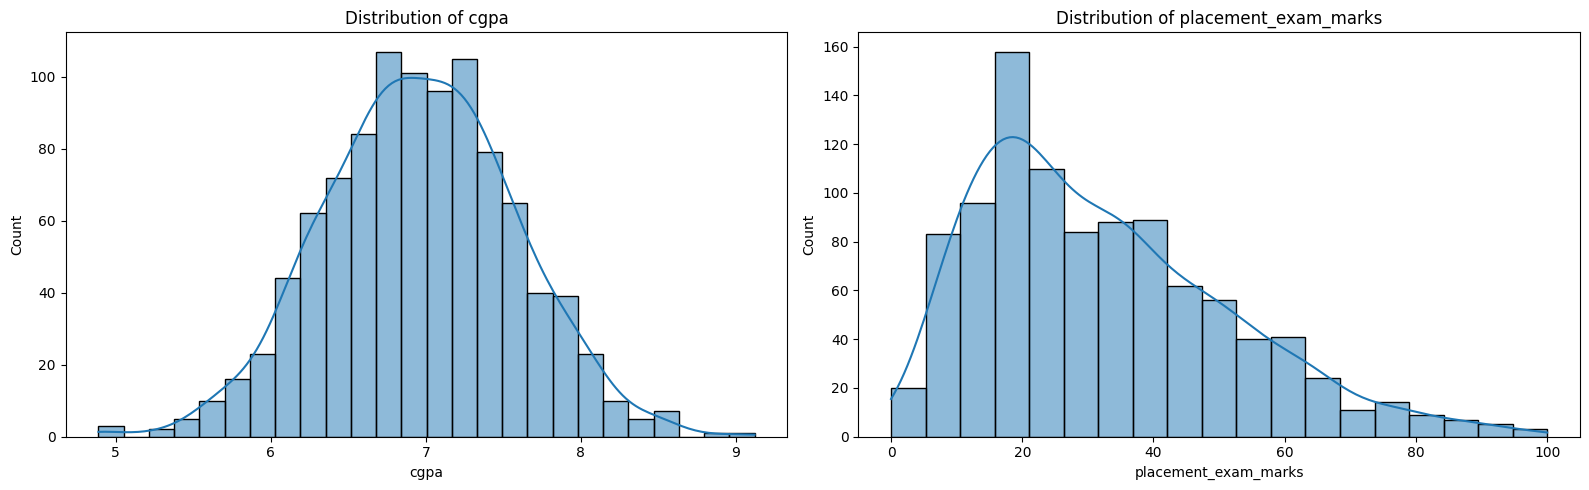

In [5]:
# Distribution plot of the features

def plot_dist(df, feat1, feat2):
    
    fig, axes = plt.subplots(1,2, figsize=(16,5))
    
    # For Feature 1:
    sns.histplot(df[feat1], ax=axes[0], kde=True)
    axes[0].set_title(f'Distribution of {feat1}')
    
    # For Feature 2:
    sns.histplot(df[feat2], kde=True, ax=axes[1])
    axes[1].set_title(f'Distribution of {feat2}')
    
    plt.tight_layout()
    plt.show()

plot_dist(df, 'cgpa', 'placement_exam_marks')

In [6]:
print("CGPA skewness:", np.round(df['cgpa'].skew(),4))
print("Exam marks skewness:", np.round(df['placement_exam_marks'].skew(),4))

# Clearly we can see that the distribution of CGPA( Can apply Z-score Method) and Exam Marks are highly skewed.
# This means that there are a lot of outliers in these columns, which can affect our analysis.
# We need to handle these outliers before proceeding with our analysis. 

CGPA skewness: -0.0145
Exam marks skewness: 0.8356


In [7]:
# Statistical Data fo Feature 'CGPA'
print(f"CGPA|  Mean:  {df['cgpa'].mean():.3f} | Standard Deviation:  {df['cgpa'].std():.3f}")
print(f"CGPA|  Max:  {df['cgpa'].max():.3f} | Min :  {df['cgpa'].min():.3f}")

CGPA|  Mean:  6.961 | Standard Deviation:  0.616
CGPA|  Max:  9.120 | Min :  4.890


In [8]:
# Finding The Boundary values
highest = np.round(df['cgpa'].mean() + 3*df['cgpa'].std(),3)
lowest = np.round(df['cgpa'].mean() - 3*df['cgpa'].std(),3)

print(f" Highest Allowed Value : {highest}")
print(f" Lowest Allowed Value : {lowest}")

 Highest Allowed Value : 8.809
 Lowest Allowed Value : 5.114


In [9]:
# Finding Outliers in our dataset
outliers = df[(df['cgpa'] > highest) | (df['cgpa'] < lowest)]
outliers

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


## 2. Outlier Handling

### 2.1 Trimming

In [10]:
# Removing the Outliers from our dataset using Trimming method.

# Method 1: 
new_df = df.drop(outliers.index)
new_df

# Or df_new = df[ (df['cgpa']< highest) & (df['cgpa']> lowest)]

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


In [11]:
# Method 2: 
df['cgpa_zscore'] = (df['cgpa'] - df['cgpa'].mean()) / df['cgpa'].std() 
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [12]:
# Extracting Values Less than and greater than the Z-Score Thresholds(-3,3)
upper_outliers = df[df['cgpa_zscore']> 3]
lower_outliers = df[df['cgpa_zscore']<-3]

print(f" Upper Outliers : {upper_outliers}")
print(f" Lower Outliers :{lower_outliers}")

# Concatenating the upper and lower outliers
outlier = pd.concat([upper_outliers, lower_outliers])
outlier

# To remove : df.drop(outlier.index)

 Upper Outliers :      cgpa  placement_exam_marks  placed  cgpa_zscore
995  8.87                  44.0       1     3.099150
996  9.12                  65.0       1     3.505062
 Lower Outliers :     cgpa  placement_exam_marks  placed  cgpa_zscore
485  4.92                  44.0       1    -3.314251
997  4.89                  34.0       0    -3.362960
999  4.90                  10.0       1    -3.346724


,cgpa,placement_exam_marks,placed,cgpa_zscore
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
485,4.92,44.0,1,-3.314251
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


### 2.2 Capping 

In [13]:
# Boundary Values : 
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

print(f" Upper Limit : {upper_limit}")
print(f" Lower Limit :{lower_limit}")

 Upper Limit : 8.808933625397168
 Lower Limit :5.113546374602832


In [14]:
# Capping all the outliers with lower and upper limit
df['cgpa'] = np.where(df['cgpa']> upper_limit, upper_limit, np.where(df['cgpa']< lower_limit, lower_limit, df['cgpa']))
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [15]:
# Shape of the data frame remain same after capping. 
df.shape

(1000, 4)

In [16]:
df['cgpa'].describe()

# Previously for 'cgpa'  Min : 4.890 and Max : 9.120
# After Applying Capping Min : 5.113 and Max : 8.808 
# Thus all the values know lies b/w new Min and Max values and there is no outliers

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64